/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

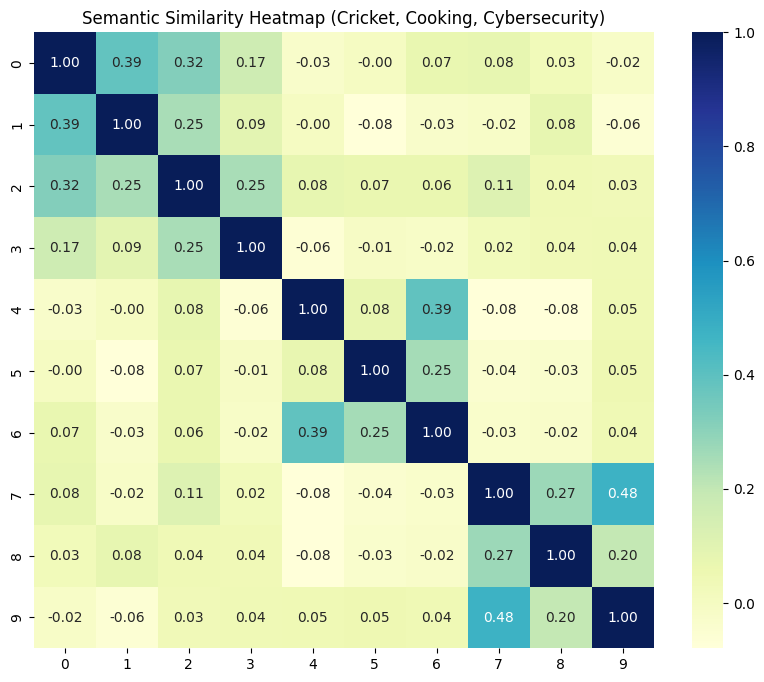


Query Sentence: 'The bowler took three wickets in one over'
--------------------------------------------------
Similarity Score: 0.5319
Matched Sentence: The batsman hit a massive six over the long-on boundary.

Similarity Score: 0.4891
Matched Sentence: The pitch conditions often favor spin bowlers in the subcontinent.



In [1]:
# Install necessary libraries
!pip install sentence-transformers seaborn matplotlib pandas numpy

from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 10 sentences across 3 topics: Cricket, Cooking, and Cybersecurity
sentences = [
    "The batsman hit a massive six over the long-on boundary.", # Cricket
    "The umpire declared the player out after a successful LBW appeal.", # Cricket
    "The pitch conditions often favor spin bowlers in the subcontinent.", # Cricket
    "T20 matches are known for their fast-paced and aggressive gameplay.", # Cricket
    "Sauté the onions until they turn golden brown and fragrant.", # Cooking
    "Baking a sourdough loaf requires a healthy starter and plenty of patience.", # Cooking
    "Whisk the egg whites until stiff peaks form for a light souffle.", # Cooking
    "Multi-factor authentication adds an essential layer of security to online accounts.", # Cybersecurity
    "A firewall acts as a barrier between a trusted network and untrusted traffic.", # Cybersecurity
    "Phishing attacks often use deceptive emails to steal sensitive user credentials." # Cybersecurity
]

# 2. Generate embeddings using the all-MiniLM-L6-v2 model
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# 3. Compute and display a 10x10 cosine similarity matrix as a heatmap
cosine_sim = util.cos_sim(embeddings, embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim.numpy(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Semantic Similarity Heatmap (Cricket, Cooking, Cybersecurity)")
plt.show()

# 4. Find top 2 most similar sentences for the new query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

# Compute similarity between query and all sentences
hits = util.semantic_search(query_embedding, embeddings, top_k=2)

print(f"\nQuery Sentence: '{query}'")
print("-" * 50)
for hit in hits[0]:
    print(f"Similarity Score: {hit['score']:.4f}")
    print(f"Matched Sentence: {sentences[hit['corpus_id']]}\n")